In [16]:
import pandas as pd
import numpy as np

In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [18]:
"""In this homework, we will use the lead scoring dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).

In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not.

Data preparation

- Check if the missing values are presented in the features.
- If there are missing values:
  - For categorical features, replace them with `NA`
  - For numerical features, replace them with `0.0`
- Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`.
"""

'In this homework, we will use the lead scoring dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).\n\nIn this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not.\n\nData preparation\n\n- Check if the missing values are presented in the features.\n- If there are missing values:\n  - For categorical features, replace them with `NA`\n  - For numerical features, replace them with `0.0`\n- Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`.\n'

In [19]:
from sklearn.model_selection import train_test_split

y = df['converted']
X = df.drop(columns='converted')

categorical_features = X.select_dtypes(include=['object', 'category', 'str']).columns
numerical_features = X.select_dtypes(include=np.number).columns

missing_values = X.isna().sum()
print(missing_values[missing_values > 0])

X[categorical_features] = X[categorical_features].fillna('NA')
X[numerical_features] = X[numerical_features].fillna(0.0)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1
)

print(f'Train: {X_train.shape}, validation: {X_val.shape}, test: {X_test.shape}')
print(f'Missing values after imputation: {X.isna().sum().sum()}')

lead_source          128
industry             134
annual_income        181
employment_status    100
location              63
dtype: int64
Train: (877, 8), validation: (292, 8), test: (293, 8)
Missing values after imputation: 0


In [20]:
"""Question 1: ROC AUC feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
Use the training dataset for that
If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

lead_score
number_of_courses_viewed
interaction_count
annual_income"""

'Question 1: ROC AUC feature importance\nROC AUC could also be used to evaluate feature importance of numerical variables.\n\nLet\'s do that\n\nFor each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.\nUse the training dataset for that\nIf your AUC is < 0.5, invert this variable by putting "-" in front\n\n(e.g. -df_train[\'balance\'])\n\nAUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.\n\nWhich numerical variable (among the following 4) has the highest AUC?\n\nlead_score\nnumber_of_courses_viewed\ninteraction_count\nannual_income'

In [21]:
from sklearn.metrics import roc_auc_score

numerical_variables = [
    'lead_score',
    'number_of_courses_viewed',
    'interaction_count',
    'annual_income',
]

feature_auc = {}
for feature in numerical_variables:
    score = roc_auc_score(y_train, X_train[feature])
    if score < 0.5:
        score = roc_auc_score(y_train, -X_train[feature])
    feature_auc[feature] = score

for feature, auc in feature_auc.items():
    print(f'{feature}: {auc:.6f}')

highest_auc_feature = max(feature_auc, key=feature_auc.get)
print(f'Highest AUC: {highest_auc_feature}')

lead_score: 0.611117
number_of_courses_viewed: 0.765244
interaction_count: 0.727191
annual_income: 0.544635
Highest AUC: number_of_courses_viewed


In [22]:
"""Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
What's the AUC of this model on the validation dataset? (round to 3 digits)"""

"Question 2: Training the model\nApply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:\n\nLogisticRegression(solver='liblinear', C=1.0, max_iter=1000)\nWhat's the AUC of this model on the validation dataset? (round to 3 digits)"

In [23]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

train_dict = X_train.to_dict(orient='records')
val_dict = X_val.to_dict(orient='records')

vectorizer = DictVectorizer(sparse=False)
X_train_encoded = vectorizer.fit_transform(train_dict)
X_val_encoded = vectorizer.transform(val_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train_encoded, y_train)

y_val_pred = model.predict_proba(X_val_encoded)[:, 1]
validation_auc = roc_auc_score(y_val, y_val_pred)
print(f'Validation AUC: {validation_auc:.3f}')

Validation AUC: 0.794


In [24]:
""""Question 3: Precision and Recall
Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
For each threshold, compute precision and recall
Plot them
At which threshold precision and recall curves intersect?"""

'"Question 3: Precision and Recall\nNow let\'s compute precision and recall for our model.\n\nEvaluate the model on all thresholds from 0.0 to 1.0 with step 0.01\nFor each threshold, compute precision and recall\nPlot them\nAt which threshold precision and recall curves intersect?'

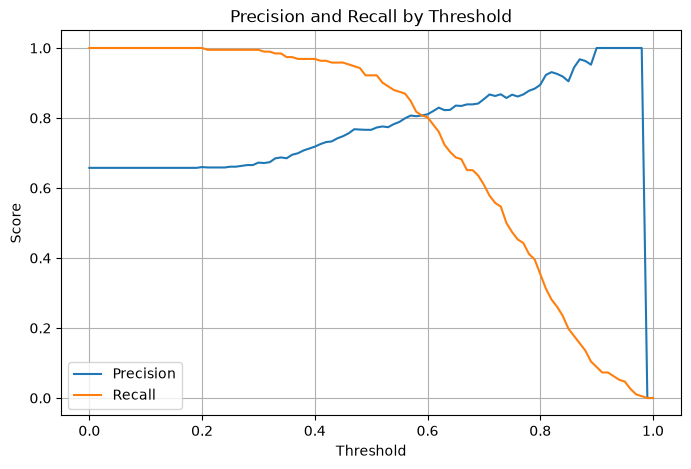

Intersection threshold: 0.59
Precision: 0.807
Recall: 0.807


In [25]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []

for threshold in thresholds:
    y_val_pred_binary = (y_val_pred >= threshold).astype(int)
    precisions.append(precision_score(y_val, y_val_pred_binary, zero_division=0))
    recalls.append(recall_score(y_val, y_val_pred_binary, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall by Threshold')
plt.legend()
plt.grid(True)
plt.show()

intersection_index = np.argmin(np.abs(np.array(precisions) - np.array(recalls)))
print(f'Intersection threshold: {thresholds[intersection_index]:.2f}')
print(f'Precision: {precisions[intersection_index]:.3f}')
print(f'Recall: {recalls[intersection_index]:.3f}')

In [26]:
"""Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F
1
=
2
⋅
P
⋅
R
P
+
R

Where 
P
 is precision and 
R
 is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

"""

"Question 4: F1 score\nPrecision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both\n\nThis is the formula for computing F1:\n\nF\n1\n=\n2\n⋅\nP\n⋅\nR\nP\n+\nR\n\nWhere \nP\n is precision and \nR\n is recall.\n\nLet's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01\n\nAt which threshold F1 is maximal?\n\n"

In [27]:
f1_scores = []

for precision, recall in zip(precisions, recalls):
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
    f1_scores.append(f1)

max_f1_index = np.argmax(f1_scores)
print(f'Maximum F1 threshold: {thresholds[max_f1_index]:.2f}')
print(f'Maximum F1 score: {f1_scores[max_f1_index]:.3f}')

Maximum F1 threshold: 0.47
Maximum F1 score: 0.848


In [28]:
"""Question 5: 5-Fold CV
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1)
Iterate over different folds of df_full_train
Split the data into train and validation
Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
Use AUC to evaluate the model on validation
How large is standard deviation of the scores across different folds?

"""

"Question 5: 5-Fold CV\nUse the KFold class from Scikit-Learn to evaluate our model on 5 different folds:\n\nKFold(n_splits=5, shuffle=True, random_state=1)\nIterate over different folds of df_full_train\nSplit the data into train and validation\nTrain the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)\nUse AUC to evaluate the model on validation\nHow large is standard deviation of the scores across different folds?\n\n"

In [29]:
from sklearn.model_selection import KFold

df_full_train = pd.concat([X_train, X_val], ignore_index=True)
y_full_train = pd.concat([y_train, y_val], ignore_index=True)

kf = KFold(n_splits=5, shuffle=True, random_state=1)
fold_auc_scores = []

for train_indices, val_indices in kf.split(df_full_train):
    df_fold_train = df_full_train.iloc[train_indices]
    df_fold_val = df_full_train.iloc[val_indices]
    y_fold_train = y_full_train.iloc[train_indices]
    y_fold_val = y_full_train.iloc[val_indices]

    fold_vectorizer = DictVectorizer(sparse=False)
    X_fold_train = fold_vectorizer.fit_transform(df_fold_train.to_dict(orient='records'))
    X_fold_val = fold_vectorizer.transform(df_fold_val.to_dict(orient='records'))

    fold_model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    fold_model.fit(X_fold_train, y_fold_train)

    y_fold_pred = fold_model.predict_proba(X_fold_val)[:, 1]
    fold_auc_scores.append(roc_auc_score(y_fold_val, y_fold_pred))

print('Fold AUC scores:', [round(score, 6) for score in fold_auc_scores])
print(f'Standard deviation: {np.std(fold_auc_scores):.6f}')

Fold AUC scores: [0.80668, 0.80675, 0.864819, 0.833438, 0.815385]
Standard deviation: 0.021987


In [30]:
"""Question 6: Hyperparameter Tuning
Now let's use 5-Fold cross-validation to find the best parameter C

Iterate over the following C values: [0.000001, 0.001, 1]
Initialize KFold with the same parameters as previously
Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
Compute the mean score as well as the std (round the mean and std to 3 decimal digits)
Which C leads to the best mean score?"""

"Question 6: Hyperparameter Tuning\nNow let's use 5-Fold cross-validation to find the best parameter C\n\nIterate over the following C values: [0.000001, 0.001, 1]\nInitialize KFold with the same parameters as previously\nUse these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)\nCompute the mean score as well as the std (round the mean and std to 3 decimal digits)\nWhich C leads to the best mean score?"

In [31]:
c_values = [0.000001, 0.001, 1]
cv_results = {}

for C in c_values:
    c_scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=1)

    for train_indices, val_indices in kf.split(df_full_train):
        df_fold_train = df_full_train.iloc[train_indices]
        df_fold_val = df_full_train.iloc[val_indices]
        y_fold_train = y_full_train.iloc[train_indices]
        y_fold_val = y_full_train.iloc[val_indices]

        fold_vectorizer = DictVectorizer(sparse=False)
        X_fold_train = fold_vectorizer.fit_transform(df_fold_train.to_dict(orient='records'))
        X_fold_val = fold_vectorizer.transform(df_fold_val.to_dict(orient='records'))

        fold_model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        fold_model.fit(X_fold_train, y_fold_train)

        y_fold_pred = fold_model.predict_proba(X_fold_val)[:, 1]
        c_scores.append(roc_auc_score(y_fold_val, y_fold_pred))

    cv_results[C] = (np.mean(c_scores), np.std(c_scores))
    print(f'C={C}: mean={np.mean(c_scores):.3f}, std={np.std(c_scores):.3f}')

best_c = max(cv_results, key=lambda value: cv_results[value][0])
print(f'Best C: {best_c}')

C=1e-06: mean=0.543, std=0.025
C=0.001: mean=0.864, std=0.014
C=1: mean=0.825, std=0.022
Best C: 0.001


## Notebook Summary

This notebook analyzes the lead scoring dataset and predicts whether a lead converted to a customer.

### Data Preparation

- Loaded the dataset from the provided GitHub URL.
- Used `converted` as the target variable.
- Checked the feature columns for missing values.
- Replaced missing categorical values with `NA` and missing numerical values with `0.0`.
- Split the data into training, validation, and test sets with a 60%/20%/20% ratio using `random_state=1`.

### Results

1. **ROC AUC feature importance:** `number_of_courses_viewed` had the highest AUC at `0.765244`.
2. **Logistic regression:** Applied one-hot encoding with `DictVectorizer` and trained logistic regression. The validation AUC was `0.794`.
3. **Precision and recall:** Evaluated thresholds from `0.00` to `1.00`. Precision and recall intersected at threshold `0.59`, with both scores approximately `0.807`.
4. **F1 score:** The maximum F1 score was `0.848` at threshold `0.47`.
5. **5-fold cross-validation:** The standard deviation of the validation AUC scores was `0.021987`.
6. **Hyperparameter tuning:** Tested `C` values of `0.000001`, `0.001`, and `1`. The best mean AUC was achieved with `C=0.001`, with mean `0.864` and standard deviation `0.014`.